# Lesson 10: Applications

End-to-end ML pipelines for Biotech and SaaS.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score, classification_report, roc_auc_score

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

## Case Study 1: Biotech Product Quality Prediction

In [2]:
n = 500
bio = pd.DataFrame({
    'temperature_c': np.random.normal(37, 2, n),
    'ph_level': np.random.normal(7.2, 0.3, n),
    'dissolved_o2': np.random.normal(60, 10, n),
    'agitation_rpm': np.random.normal(200, 30, n),
    'feed_rate': np.random.normal(50, 10, n),
    'culture_time': np.random.normal(120, 20, n),
    'cell_density': np.random.normal(10, 3, n),
})
quality = (80 - 2*np.abs(bio['temperature_c']-37) - 5*np.abs(bio['ph_level']-7.2)
           - 0.3*np.abs(bio['dissolved_o2']-60) + 0.02*bio['cell_density']
           + np.random.normal(0, 3, n))
bio['quality_score'] = quality.clip(0, 100)

In [3]:
X = bio.drop('quality_score', axis=1)
y = bio['quality_score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = []
for name, model in models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    results.append({'Model': name, 'R2': r2_score(y_test, y_pred),
                    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred))})

pd.DataFrame(results).round(3)

,Model,R2,RMSE
0,Linear Regression,0.018,4.617
1,Random Forest,0.483,3.348
2,Gradient Boosting,0.505,3.277


## Feature Importance for Biotech

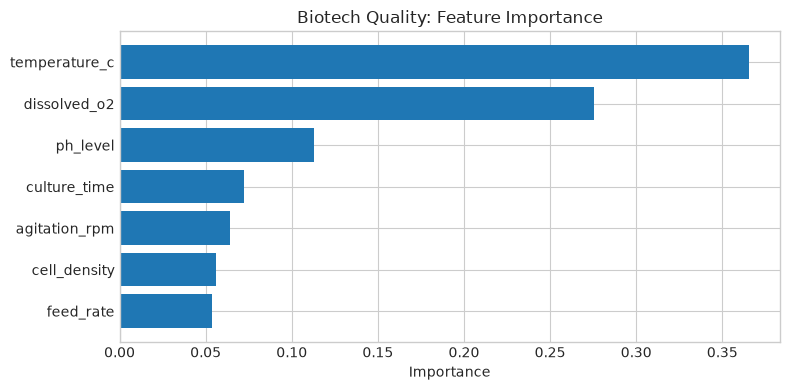

In [4]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

imp = pd.DataFrame({'feature': X.columns, 'importance': rf.feature_importances_})
imp = imp.sort_values('importance', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(imp['feature'], imp['importance'])
plt.xlabel('Importance')
plt.title('Biotech Quality: Feature Importance')
plt.tight_layout()
plt.show()

## Case Study 2: SaaS Customer Segmentation & Churn

In [5]:
n_c = 1000
saas = pd.DataFrame({
    'monthly_spend': np.random.exponential(200, n_c),
    'logins_per_week': np.random.poisson(5, n_c),
    'features_used': np.random.poisson(8, n_c),
    'support_tickets': np.random.poisson(1, n_c),
    'account_age': np.random.exponential(18, n_c),
    'days_since_login': np.random.exponential(14, n_c),
})
log_odds = (-1 + 0.05*saas['days_since_login'] + 0.3*saas['support_tickets']
            - 0.02*saas['logins_per_week'] - 0.1*saas['features_used'])
saas['churned'] = (1/(1+np.exp(-log_odds)) > 0.3).astype(int)

In [6]:
# Step 1: Segmentation
X_seg = StandardScaler().fit_transform(saas.drop('churned', axis=1))
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
saas['segment'] = kmeans.fit_predict(X_seg)

profiles = saas.groupby('segment').mean().round(1)
print("Segment Profiles:")
print(profiles)

Segment Profiles:
         monthly_spend  logins_per_week  features_used  support_tickets  \
segment                                                                   
0                220.2              4.9            8.0              2.5   
1                204.0              4.8            8.1              0.5   
2                152.8              5.4            8.7              1.1   

         account_age  days_since_login  churned  
segment                                          
0               13.3              14.8      0.6  
1               12.7              14.0      0.3  
2               60.0              12.7      0.4  


In [7]:
# Step 2: Churn prediction per segment
for seg in sorted(saas['segment'].unique()):
    seg_data = saas[saas['segment'] == seg]
    X_s = seg_data.drop(['churned', 'segment'], axis=1)
    y_s = seg_data['churned']
    if len(seg_data) < 50:
        continue
    Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(X_s, y_s, test_size=0.3, random_state=42)
    rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    rf.fit(Xs_tr, ys_tr)
    auc = roc_auc_score(ys_te, rf.predict_proba(Xs_te)[:, 1])
    print(f"Segment {seg} (n={len(seg_data)}): Churn AUC = {auc:.3f}")

Segment 0 (n=261): Churn AUC = 0.988


Segment 1 (n=617): Churn AUC = 0.989
Segment 2 (n=122): Churn AUC = 0.972


## Pipeline with Mixed Data Types

In [8]:
bio_mixed = bio.copy()
bio_mixed['batch_type'] = np.random.choice(['A', 'B', 'C'], n)

X_mixed = bio_mixed.drop('quality_score', axis=1)
y_mixed = bio_mixed['quality_score']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), X_mixed.select_dtypes(include=[np.number]).columns),
    ('cat', OneHotEncoder(drop='first'), ['batch_type']),
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42)),
])

param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [5, 10, None],
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2')
grid.fit(X_mixed, y_mixed)

print(f"Best params: {grid.best_params_}")
print(f"Best CV R²: {grid.best_score_:.3f}")
print(f"Test R²: {r2_score(y_mixed, grid.predict(X_mixed)):.3f}")

Best params: {'model__max_depth': 10, 'model__n_estimators': 200}
Best CV R²: 0.431
Test R²: 0.856


## Exercises

### Level 1
What are the 5 key stages of an end-to-end ML pipeline?

### Level 2
Build a pipeline for biotech quality with GridSearchCV over n_estimators and max_depth.

### Level 3
Your model has R²=0.92 but manufacturing doesn't trust it. What do you do?

In [9]:
# Level 2 code

## Coding Challenge

Write `build_ml_pipeline(X, y, model, param_grid)` returning best pipeline and CV results.

In [10]:
def build_ml_pipeline(X, y, model, param_grid):
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model),
    ])
    grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2')
    grid.fit(X, y)
    results = pd.DataFrame(grid.cv_results_)
    print(f"Best params: {grid.best_params_}")
    print(f"Best CV R²: {grid.best_score_:.3f}")
    return grid.best_estimator_, results

best_pipe, cv_results = build_ml_pipeline(
    X_train, y_train,
    RandomForestRegressor(random_state=42),
    {'model__n_estimators': [50, 100], 'model__max_depth': [5, 10]}
)

Best params: {'model__max_depth': 5, 'model__n_estimators': 100}
Best CV R²: 0.409


## Summary

- Biotech: predict quality from process parameters
- SaaS: segment customers → predict churn per segment
- Pipeline + ColumnTransformer for mixed data
- GridSearchCV for systematic tuning
- Communication is as important as accuracy
- You now have all the tools for the final project!